# 405 — Ablación de índices de vegetación

**Corrección de jurado C #17**

Cuantifica el aporte real de los 5 índices de vegetación (NDVI, NDRE, CIgreen, PRI, PSRI) mediante **ablación durante inferencia**. No se reentrena ningún modelo.

**Regla de neutralización:** cada feature ablacionado se reemplaza por la media del training set en el espacio de entrada de cada arquitectura (espacio original para ML; espacio escalado para CNN).

**Salidas:**
- `reports/figures/iv_ablation/iv_ablation_results.csv`
- `reports/figures/iv_ablation/iv_ablation_summary.{csv,md,png,pdf}`
- `reports/figures/iv_ablation/iv_individual_contribution.{png,pdf}`

## Librerías

In [1]:
import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

## 0. Imports y configuración

In [2]:
import os, sys, json, warnings
# sys.stdout.reconfigure(encoding="utf-8")
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score,
)
warnings.filterwarnings("ignore")
%matplotlib inline


In [3]:
package_path = os.path.abspath("..").split(os.sep + "notebooks")[0]
if package_path not in sys.path:
    sys.path.insert(0, package_path)

from spectralcrop.utils.path_manager import PathManager

PM = PathManager()

def _resolve(p):
    if isinstance(p, list):
        return [x for x in p if "spectralcrop" not in x][0]
    return p

INTERIM_PATH   = _resolve(PM.get_abs_path_folder("interim"))
PROCESSED_PATH = _resolve(PM.get_abs_path_folder("processed"))
MODELS_PATH    = Path(_resolve(PM.get_abs_path_folder("models")))
REPORTS_PATH   = _resolve(PM.get_abs_path_folder("reports"))

ZARR_PATH   = INTERIM_PATH + "masked_reflectance.zarr"
LABELS_PATH = _resolve(PM.get_abs_path_file("labels_multiclass.tif"))
SPLIT_PATH  = PROCESSED_PATH + "/splits/by_plot_split_id_binary.tif"
BANDS_PATH  = _resolve(PM.get_abs_path_file("bands_selected_by_segment.csv"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"ZARR   : {ZARR_PATH}")
print(f"Models : {MODELS_PATH}")


Device : cuda
ZARR   : c:\Users\mario\Documentos\personal_projects\thesis\data\interim\masked_reflectance.zarr
Models : c:\Users\mario\Documentos\personal_projects\thesis\models


In [4]:
FIGS_IV = Path(REPORTS_PATH) / "figures" / "iv_ablation"
FIGS_IV.mkdir(parents=True, exist_ok=True)
print(f"Output: {FIGS_IV}")


Output: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\iv_ablation


## 1. Arquitecturas DL

In [5]:
class Spectral1DCNN(nn.Module):
    def __init__(self, n_classes=2, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv1d(1, 16, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool  = nn.AdaptiveAvgPool1d(8)
        self.fc1   = nn.Linear(32 * 8, 64)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


class SpectralSpatialCNN2D(nn.Module):
    def __init__(self, n_channels=63, n_classes=2, dropout=0.3, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(n_channels, 32, kernel_size=kernel_size, padding=pad)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=pad)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=kernel_size, padding=pad)
        self.bn3   = nn.BatchNorm2d(128)
        self.pool  = nn.AdaptiveAvgPool2d((2, 2))
        self.fc1   = nn.Linear(128 * 2 * 2, 128)
        self.drop  = nn.Dropout(dropout)
        self.fc2   = nn.Linear(128, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)


## 2. Carga de datos

In [6]:
# Feature layout (63 channels):
#   0-4  : NDVI, NDRE, CIgreen, PRI, PSRI
#   5-62 : 58 selected spectral bands

ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

bands_df       = pd.read_csv(BANDS_PATH)
selected_bands = bands_df["band_index"].tolist()
assert len(selected_bands) == 58

indices_da           = ds[["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]].to_array(dim="band")
reflectance_selected = ds["reflectance"].isel(band=selected_bands)
features_stack       = xr.concat([indices_da, reflectance_selected], dim="band")
features_stack       = features_stack.transpose("y", "x", "band")

VI_NAMES     = ["NDVI", "NDRE", "CIgreen", "PRI", "PSRI"]
VI_INDICES   = list(range(5))
SPECTRAL_IDX = list(range(5, 63))

print(f"Feature cube: {features_stack.sizes}")

# Labels: 0=non-stressed, 1=stressed, NaN=invalid
with rasterio.open(LABELS_PATH) as src:
    labels_raw = src.read(1)
labels_bin = np.where(labels_raw == 0, 0,
             np.where(np.isin(labels_raw, [1, 2, 3]), 1, np.nan))

# Split map: 1=train, 2=val, 3=test
with rasterio.open(SPLIT_PATH) as src:
    split_map = src.read(1)

print("Loading feature cube into memory...")
X_cube = features_stack.values  # (H, W, 63)
H, W, B = X_cube.shape

X_flat      = X_cube.reshape(-1, B)
labels_flat = labels_bin.reshape(-1, 1)
split_flat  = np.where(split_map == 0, np.nan, split_map.astype(float)).reshape(-1, 1)
data_full   = np.concatenate([X_flat, labels_flat, split_flat], axis=1)

df_full = pd.DataFrame(data_full).dropna(axis=0, how="any")
df_full.rename(columns={df_full.columns[-2]: "label",
                         df_full.columns[-1]: "split"}, inplace=True)

X_all     = df_full.drop(columns=["label", "split"]).values
y_all     = df_full["label"].values
split_all = df_full["split"].values

X_train = X_all[split_all == 1];  y_train = y_all[split_all == 1]
X_val   = X_all[split_all == 2];  y_val   = y_all[split_all == 2]
X_test  = X_all[split_all == 3];  y_test  = y_all[split_all == 3]

print(f"train={len(X_train):,}  val={len(X_val):,}  test={len(X_test):,}")
print(f"test: 0={int((y_test==0).sum()):,}  1={int((y_test==1).sum()):,}")


Feature cube: Frozen({'y': 3660, 'x': 3438, 'band': 63})
Loading feature cube into memory...
train=1,009,179  val=343,275  test=361,810
test: 0=92,596  1=269,214


## 3. Escalado + parches CNN-2D (test)

> El bucle anidado puede tardar varios minutos.

In [7]:
scaler_ext     = joblib.load(MODELS_PATH / "robust_scaler.pkl")
X_train_scaled = scaler_ext.transform(X_train)
X_val_scaled   = scaler_ext.transform(X_val)
X_test_scaled  = scaler_ext.transform(X_test)

print("Scaling feature cube...")
cube_scaled = scaler_ext.transform(X_cube.reshape(-1, B)).reshape(H, W, B)

# Training-set means used for ablation neutralisation
TRAIN_MEAN_SCALED = X_train_scaled.mean(axis=0)
TRAIN_MEAN_ORIG   = X_train.mean(axis=0)


def build_patch_dataset(cube, labels_2d, split_2d, split_value, patch=5):
    """Extract CNN-2D patches. Border and NaN-neighbourhood pixels excluded."""
    Hc, Wc, Bc = cube.shape
    r = patch // 2
    X_list, y_list = [], []
    for i in range(r, Hc - r):
        for j in range(r, Wc - r):
            if split_2d[i, j] != split_value:
                continue
            if np.isnan(labels_2d[i, j]):
                continue
            patch_cube = cube[i-r:i+r+1, j-r:j+r+1, :]
            if np.isnan(patch_cube).any():
                continue
            X_list.append(np.transpose(patch_cube, (2, 0, 1)))
            y_list.append(labels_2d[i, j])
    return np.stack(X_list), np.array(y_list, dtype=np.int64)


PATCH = 5
print("Building CNN-2D test patches (may take several minutes)...")
X_test2d, y_test2d = build_patch_dataset(cube_scaled, labels_bin, split_map, 3, PATCH)
print(f"test2d={len(X_test2d):,}  "
      f"(0={int((y_test2d==0).sum()):,}, 1={int((y_test2d==1).sum()):,})")


Scaling feature cube...
Building CNN-2D test patches (may take several minutes)...
test2d=251,856  (0=60,116, 1=191,740)


## 4. Carga de modelos finales

In [8]:
ml_files = {
    "LogisticRegression": "logreg_cv_final_model.pkl",
    "SGDClassifier":      "sgd_cv_final_model.pkl",
    "LightGBM":           "lgbm_cv_final_model.pkl",
    "XGBoost":            "xgboost_cv_final_model.pkl",
}
ml_models = {n: joblib.load(MODELS_PATH / f) for n, f in ml_files.items()}

with open(MODELS_PATH / "cnn1d_final_model_info.json") as f:
    info1d = json.load(f)
model1d = Spectral1DCNN(n_classes=2, kernel_size=info1d["kernel_size"],
                         dropout=info1d["dropout"]).to(DEVICE)
model1d.load_state_dict(torch.load(MODELS_PATH / "cnn1d_final_model_weights.pt",
                                    map_location=DEVICE, weights_only=False))
model1d.eval()
THR_1D = info1d["best_thr"]

with open(MODELS_PATH / "cnn2d_final_model_info.json") as f:
    info2d = json.load(f)
model2d = SpectralSpatialCNN2D(n_channels=info2d["n_channels"], n_classes=2,
                                kernel_size=info2d["kernel_size"],
                                dropout=info2d["dropout"]).to(DEVICE)
model2d.load_state_dict(torch.load(MODELS_PATH / "cnn2d_final_model_weights.pt",
                                    map_location=DEVICE, weights_only=False))
model2d.eval()
THR_2D = info2d["best_thr"]

print("Models loaded")
print(f"  CNN-1D thr={THR_1D:.4f}  CNN-2D thr={THR_2D:.4f}")


Models loaded
  CNN-1D thr=0.4505  CNN-2D thr=0.3218


## 5. Umbrales y predicciones base

In [9]:
def find_best_thr(y_true, y_prob):
    grid = np.linspace(0.10, 0.90, 161)
    return float(max(grid, key=lambda t: f1_score(y_true, (y_prob >= t).astype(int),
                                                   average="macro")))

def predict_proba_1d(model, X, batch_size=512):
    model.eval()
    probs = []
    Xt = torch.from_numpy(X.astype(np.float32)).unsqueeze(1)
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            probs.extend(torch.softmax(model(Xt[i:i+batch_size].to(DEVICE)), 1)[:, 1].cpu().numpy())
    return np.array(probs)

def predict_proba_2d(model, X, batch_size=256):
    model.eval()
    probs = []
    Xt = torch.from_numpy(X.astype(np.float32))
    with torch.no_grad():
        for i in range(0, len(Xt), batch_size):
            probs.extend(torch.softmax(model(Xt[i:i+batch_size].to(DEVICE)), 1)[:, 1].cpu().numpy())
    return np.array(probs)

MODEL_ORDER = ["LogisticRegression", "SGDClassifier", "LightGBM", "XGBoost", "CNN-1D", "CNN-2D"]

ml_thresholds = {}
for name, pipe in ml_models.items():
    p_val = pipe.predict_proba(X_val)[:, 1]
    ml_thresholds[name] = find_best_thr(y_val, p_val)
    print(f"  {name}: thr={ml_thresholds[name]:.4f}")

ml_probs_test = {n: p.predict_proba(X_test)[:, 1] for n, p in ml_models.items()}
ml_preds_test = {n: (p >= ml_thresholds[n]).astype(int) for n, p in ml_probs_test.items()}

p_test_1d = predict_proba_1d(model1d, X_test_scaled)
y_pred_1d = (p_test_1d >= THR_1D).astype(int)

p_test_2d = predict_proba_2d(model2d, X_test2d)
y_pred_2d = (p_test_2d >= THR_2D).astype(int)

all_probs = {**ml_probs_test, "CNN-1D": p_test_1d, "CNN-2D": p_test_2d}
all_preds = {**ml_preds_test, "CNN-1D": y_pred_1d, "CNN-2D": y_pred_2d}
all_ytrue = {m: y_test for m in MODEL_ORDER[:5]}; all_ytrue["CNN-2D"] = y_test2d
all_thr   = {**ml_thresholds, "CNN-1D": THR_1D, "CNN-2D": THR_2D}

print("\nTest-set sizes:")
for m in MODEL_ORDER:
    print(f"  {m}: {len(all_ytrue[m]):,}")


  LogisticRegression: thr=0.4450
  SGDClassifier: thr=0.4350
  LightGBM: thr=0.6950
  XGBoost: thr=0.4500

Test-set sizes:
  LogisticRegression: 361,810
  SGDClassifier: 361,810
  LightGBM: 361,810
  XGBoost: 361,810
  CNN-1D: 361,810
  CNN-2D: 251,856


## 6. C #17 — Protocolo de ablación

| Condición | Features ablacionadas | Descripción |
|---|---|---|
| C0\_all | ninguna | Baseline: todas las 63 |
| C1\_no\_VI | 0–4 | Sin IV → solo 58 bandas |
| C2\_only\_VI | 5–62 | Sin bandas → solo 5 IV |
| C3\_no\_X | 1 IV específico | Ablación individual |

In [10]:
CONDITIONS = {
    "C0_all":      [],
    "C1_no_VI":    VI_INDICES,
    "C2_only_VI":  SPECTRAL_IDX,
    "C3_no_NDVI":  [0],
    "C3_no_NDRE":  [1],
    "C3_no_CIg":   [2],
    "C3_no_PRI":   [3],
    "C3_no_PSRI":  [4],
}
VI_COND_KEYS = ["C3_no_NDVI", "C3_no_NDRE", "C3_no_CIg", "C3_no_PRI", "C3_no_PSRI"]


def compute_metrics(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "PR-AUC":      round(average_precision_score(y_true, y_prob), 4),
        "ROC-AUC":     round(roc_auc_score(y_true, y_prob), 4),
        "F1-macro":    round(f1_score(y_true, y_pred, average="macro"), 4),
        "Recall_1":    round(recall_score(y_true, y_pred), 4),
        "Precision_1": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Accuracy":    round(accuracy_score(y_true, y_pred), 4),
    }


def ablate_ml(pipe, X, train_mean_orig, indices):
    """Neutralise features in original space, then pass through the pipeline."""
    X_abl = X.copy()
    for idx in indices:
        X_abl[:, idx] = train_mean_orig[idx]
    return pipe.predict_proba(X_abl)[:, 1]


def ablate_1d(model, X_scaled, train_mean_scaled, indices):
    """Neutralise features in scaled space for CNN-1D."""
    X_abl = X_scaled.copy()
    for idx in indices:
        X_abl[:, idx] = train_mean_scaled[idx]
    return predict_proba_1d(model, X_abl)


def ablate_2d(model, X_patches, train_mean_scaled, indices):
    """Neutralise a channel across all patch positions (avoids patch rebuild)."""
    X_abl = X_patches.copy()
    for idx in indices:
        X_abl[:, idx, :, :] = train_mean_scaled[idx]
    return predict_proba_2d(model, X_abl)


print(f"Conditions : {list(CONDITIONS.keys())}")
print(f"Models     : {MODEL_ORDER}")
print(f"Total runs : {len(CONDITIONS)} x {len(MODEL_ORDER)} = {len(CONDITIONS)*len(MODEL_ORDER)}")


Conditions : ['C0_all', 'C1_no_VI', 'C2_only_VI', 'C3_no_NDVI', 'C3_no_NDRE', 'C3_no_CIg', 'C3_no_PRI', 'C3_no_PSRI']
Models     : ['LogisticRegression', 'SGDClassifier', 'LightGBM', 'XGBoost', 'CNN-1D', 'CNN-2D']
Total runs : 8 x 6 = 48


## 7. Ejecución de la rejilla (9 condiciones × 6 modelos)

In [13]:
ablation_results = []

for cond_key, ablate_idx in CONDITIONS.items():
    label = f"{len(ablate_idx)} feat" if len(ablate_idx) > 5 else str(ablate_idx)
    print(f"\n  {cond_key}  (ablate: {label})")

    for model_name in MODEL_ORDER:
        thr = all_thr[model_name]

        if model_name in ml_models:
            p = (ml_models[model_name].predict_proba(X_test)[:, 1] if not ablate_idx
                 else ablate_ml(ml_models[model_name], X_test, TRAIN_MEAN_ORIG, ablate_idx))
            y_true = y_test

        elif model_name == "CNN-1D":
            p = (predict_proba_1d(model1d, X_test_scaled) if not ablate_idx
                 else ablate_1d(model1d, X_test_scaled, TRAIN_MEAN_SCALED, ablate_idx))
            y_true = y_test

        else:  # CNN-2D: ablation on pre-extracted patches, y_true always = y_test2d
            p = (p_test_2d if not ablate_idx
                 else ablate_2d(model2d, X_test2d, TRAIN_MEAN_SCALED, ablate_idx))
            y_true = y_test2d

        metrics = compute_metrics(y_true, p, thr)
        ablation_results.append({"Modelo": model_name, "Condicion": cond_key, **metrics})
        print(f"    {model_name}: PR-AUC={metrics['PR-AUC']:.4f}")

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv(FIGS_IV / "iv_ablation_results.csv", index=False)
print(f"\nFull results: {FIGS_IV} / 'iv_ablation_results.csv'")
df_ablation.head(12)



  C0_all  (ablate: [])
    LogisticRegression: PR-AUC=0.7902
    SGDClassifier: PR-AUC=0.7885
    LightGBM: PR-AUC=0.7824
    XGBoost: PR-AUC=0.8236
    CNN-1D: PR-AUC=0.8341
    CNN-2D: PR-AUC=0.9635

  C1_no_VI  (ablate: [0, 1, 2, 3, 4])
    LogisticRegression: PR-AUC=0.7811
    SGDClassifier: PR-AUC=0.7785
    LightGBM: PR-AUC=0.7699
    XGBoost: PR-AUC=0.7975
    CNN-1D: PR-AUC=0.8189
    CNN-2D: PR-AUC=0.9105

  C2_only_VI  (ablate: 58 feat)
    LogisticRegression: PR-AUC=0.7652
    SGDClassifier: PR-AUC=0.7649
    LightGBM: PR-AUC=0.7441
    XGBoost: PR-AUC=0.7714
    CNN-1D: PR-AUC=0.7637
    CNN-2D: PR-AUC=0.8018

  C3_no_NDVI  (ablate: [0])
    LogisticRegression: PR-AUC=0.7829
    SGDClassifier: PR-AUC=0.7810
    LightGBM: PR-AUC=0.7811
    XGBoost: PR-AUC=0.8185
    CNN-1D: PR-AUC=0.8242
    CNN-2D: PR-AUC=0.9291

  C3_no_NDRE  (ablate: [1])
    LogisticRegression: PR-AUC=0.7810
    SGDClassifier: PR-AUC=0.7784
    LightGBM: PR-AUC=0.7824
    XGBoost: PR-AUC=0.8035
    CNN-

,Modelo,Condicion,PR-AUC,ROC-AUC,F1-macro,Recall_1,Precision_1,Accuracy
0,LogisticRegression,C0_all,0.7902,0.5526,0.5181,0.6718,0.7583,0.5965
1,SGDClassifier,C0_all,0.7885,0.5505,0.5178,0.6905,0.7564,0.6042
2,LightGBM,C0_all,0.7824,0.5445,0.4824,0.9123,0.7461,0.7037
3,XGBoost,C0_all,0.8236,0.6151,0.5613,0.7201,0.7818,0.6422
4,CNN-1D,C0_all,0.8341,0.6355,0.5769,0.7211,0.7925,0.6519
5,CNN-2D,C0_all,0.9635,0.8889,0.7747,0.8861,0.8953,0.8344
6,LogisticRegression,C1_no_VI,0.7811,0.5353,0.5057,0.6541,0.7514,0.5816
7,SGDClassifier,C1_no_VI,0.7785,0.5320,0.5050,0.6692,0.7496,0.5876
8,LightGBM,C1_no_VI,0.7699,0.5230,0.4860,0.8676,0.7435,0.6788
9,XGBoost,C1_no_VI,0.7975,0.5725,0.5338,0.7272,0.7635,0.6294


## 8. Tabla resumen C0 vs C1 vs C2

In [14]:
df_c012 = df_ablation[df_ablation["Condicion"].isin(["C0_all","C1_no_VI","C2_only_VI"])].copy()
pivot   = df_c012.pivot(index="Modelo", columns="Condicion", values="PR-AUC").reindex(MODEL_ORDER)
pivot.columns.name = None
pivot["ΔC0-C1"]   = (pivot["C0_all"] - pivot["C1_no_VI"]).round(4)
pivot["Δ% C0-C1"] = ((pivot["ΔC0-C1"] / pivot["C0_all"]) * 100).round(2)

print("PR-AUC: C0 vs C1 vs C2")
print(pivot.to_string())

pivot.to_csv(FIGS_IV / "iv_ablation_summary.csv")
md_lines = [
    "# Ablación de índices de vegetación — Corrección C #17", "",
    "## PR-AUC: C0 (todas) vs C1 (sin IV) vs C2 (solo IV)", "",
    pivot.reset_index().to_markdown(index=False), "",
    "**Interpretación (ΔPR-AUC = C0 − C1):**",
    "- < 0.02 → IV **redundantes** (aporte marginal)",
    "- 0.02–0.05 → IV **complementarios** (aporte modesto)",
    "- ≥ 0.05 → IV **significativos**",
]
(FIGS_IV / "iv_ablation_summary.md").write_text("\n".join(md_lines), encoding="utf-8")
pivot


PR-AUC: C0 vs C1 vs C2
                    C0_all  C1_no_VI  C2_only_VI  ΔC0-C1  Δ% C0-C1
Modelo                                                            
LogisticRegression  0.7902    0.7811      0.7652  0.0091      1.15
SGDClassifier       0.7885    0.7785      0.7649  0.0100      1.27
LightGBM            0.7824    0.7699      0.7441  0.0125      1.60
XGBoost             0.8236    0.7975      0.7714  0.0261      3.17
CNN-1D              0.8341    0.8189      0.7637  0.0152      1.82
CNN-2D              0.9635    0.9105      0.8018  0.0530      5.50


,C0_all,C1_no_VI,C2_only_VI,ΔC0-C1,Δ% C0-C1
Modelo,,,,,
LogisticRegression,0.7902,0.7811,0.7652,0.0091,1.15
SGDClassifier,0.7885,0.7785,0.7649,0.0100,1.27
LightGBM,0.7824,0.7699,0.7441,0.0125,1.60
XGBoost,0.8236,0.7975,0.7714,0.0261,3.17
CNN-1D,0.8341,0.8189,0.7637,0.0152,1.82
CNN-2D,0.9635,0.9105,0.8018,0.0530,5.50


## 9. Figura A — Comparativa C0 / C1 / C2 por modelo

Saved: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\iv_ablation / f'iv_ablation_summary.png'
Saved: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\iv_ablation / f'iv_ablation_summary.pdf'


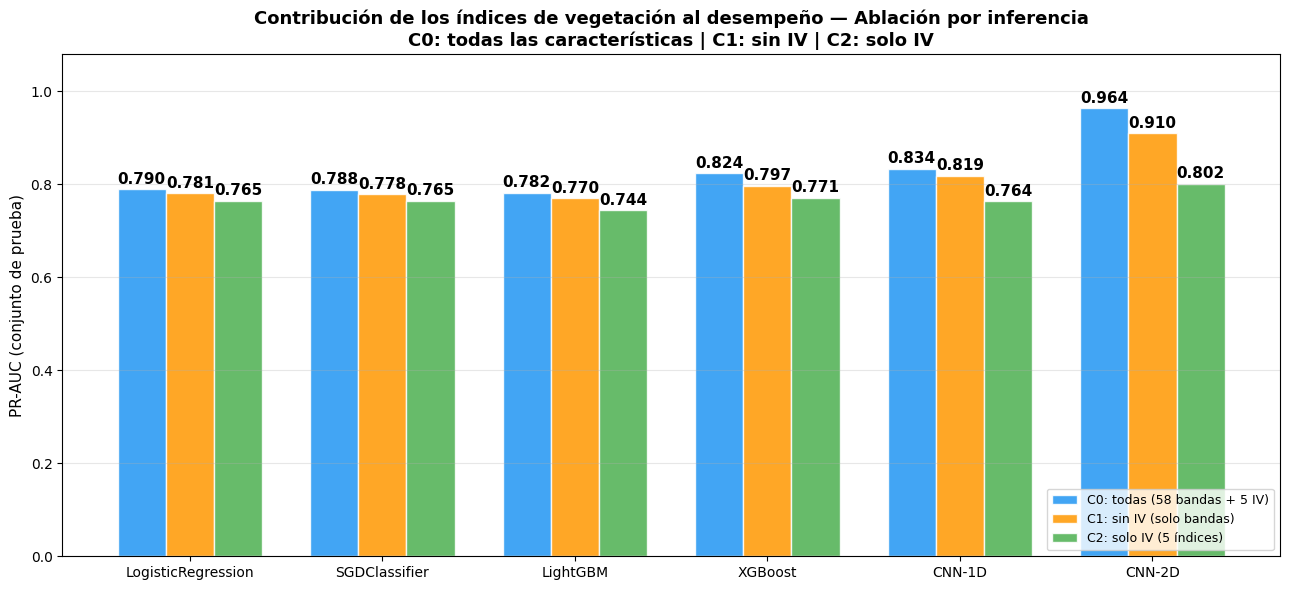

In [19]:
COLORS      = {"C0_all": "#2196F3", "C1_no_VI": "#FF9800", "C2_only_VI": "#4CAF50"}
COND_LABELS = {
    "C0_all":     "C0: todas (58 bandas + 5 IV)",
    "C1_no_VI":   "C1: sin IV (solo bandas)",
    "C2_only_VI": "C2: solo IV (5 índices)",
}

x, width = np.arange(len(MODEL_ORDER)), 0.25
fig, ax = plt.subplots(figsize=(13, 6))

for k, (cond, color) in enumerate(COLORS.items()):
    vals = [df_ablation[(df_ablation.Modelo == m) & (df_ablation.Condicion == cond)]["PR-AUC"].values[0]
            for m in MODEL_ORDER]
    bars = ax.bar(x + (k - 1) * width, vals, width,
                  label=COND_LABELS[cond], color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel("PR-AUC (conjunto de prueba)", fontsize=11)
ax.set_title(
    "Contribución de los índices de vegetación al desempeño — Ablación por inferencia\n"
    "C0: todas las características | C1: sin IV | C2: solo IV",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9, loc="lower right"); ax.grid(axis="y", alpha=0.3)
# ax.axhline(0.75, color="red", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIGS_IV / f"iv_ablation_summary.{ext}", dpi=300, bbox_inches="tight")
    print(f"Saved: {FIGS_IV} / f'iv_ablation_summary.{ext}'")
plt.show()


## 10. Figura B — Contribución individual de cada IV (heatmap)

ΔPR-AUC = C0 − C3.IV  (positivo = el IV aporta)
                      NDVI    NDRE  CIgreen     PRI    PSRI
LogisticRegression  0.0073  0.0092   0.0007  0.0014  0.0010
SGDClassifier       0.0075  0.0101   0.0009  0.0020  0.0010
LightGBM            0.0013  0.0000   0.0003  0.0000  0.0102
XGBoost             0.0051  0.0201   0.0082  0.0006  0.0060
CNN-1D              0.0099  0.0261   0.0099  0.0013  0.0037
CNN-2D              0.0344  0.0733   0.0322  0.0034  0.0034
Saved: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\iv_ablation / f'iv_individual_contribution.png'
Saved: c:\Users\mario\Documentos\personal_projects\thesis\reports\figures\iv_ablation / f'iv_individual_contribution.pdf'


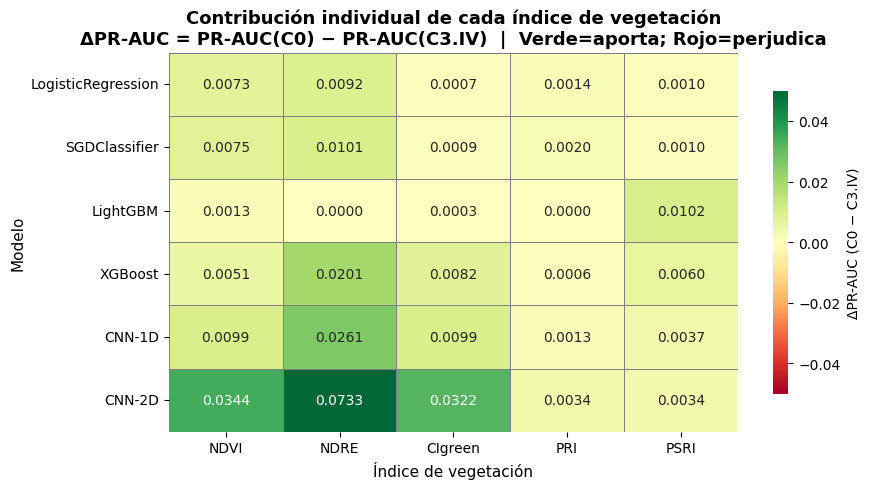

In [21]:
vi_contrib = np.zeros((len(MODEL_ORDER), len(VI_NAMES)))
for i, m in enumerate(MODEL_ORDER):
    c0 = df_ablation[(df_ablation.Modelo == m) & (df_ablation.Condicion == "C0_all")]["PR-AUC"].values[0]
    for j, ck in enumerate(VI_COND_KEYS):
        c3 = df_ablation[(df_ablation.Modelo == m) & (df_ablation.Condicion == ck)]["PR-AUC"].values[0]
        vi_contrib[i, j] = round(c0 - c3, 4)

df_hm = pd.DataFrame(vi_contrib, index=MODEL_ORDER, columns=VI_NAMES)
print("ΔPR-AUC = C0 − C3.IV  (positivo = el IV aporta)")
print(df_hm.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(df_hm, ax=ax, annot=True, fmt=".4f", cmap="RdYlGn",
            center=0, vmin=-0.05, vmax=0.05,
            linewidths=0.5, linecolor="gray",
            cbar_kws={"label": "ΔPR-AUC (C0 − C3.IV)", "shrink": 0.8})
ax.set_title(
    "Contribución individual de cada índice de vegetación\n"
    "ΔPR-AUC = PR-AUC(C0) − PR-AUC(C3.IV)  |  Verde=aporta; Rojo=perjudica",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Índice de vegetación", fontsize=11)
ax.set_ylabel("Modelo", fontsize=11)
plt.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIGS_IV / f"iv_individual_contribution.{ext}", dpi=300, bbox_inches="tight")
    print(f"Saved: {FIGS_IV} / f'iv_individual_contribution.{ext}'")
plt.show()


## 11. Interpretación basada en magnitudes observadas

In [22]:
print("=" * 68)
print("INTERPRETACIÓN — C #17")
print("=" * 68)

for m in MODEL_ORDER:
    delta = pivot.loc[m, "ΔC0-C1"]
    if delta < 0.02:
        cat = "REDUNDANTE (< 0.02)"
    elif delta < 0.05:
        cat = "COMPLEMENTARIA (0.02–0.05)"
    else:
        cat = "SIGNIFICATIVA (≥ 0.05)"
    print(f"  {m:<22} Δ={delta:.4f}  → IV son {cat}")

print()
print("Índice más influyente por modelo (ΔPR-AUC individual más alto):")
for i, m in enumerate(MODEL_ORDER):
    deltas = {vi: vi_contrib[i, j] for j, vi in enumerate(VI_NAMES)}
    best_vi = max(deltas, key=deltas.get)
    print(f"  {m:<22} {best_vi}  (Δ={deltas[best_vi]:.4f})")


INTERPRETACIÓN — C #17
  LogisticRegression     Δ=0.0091  → IV son REDUNDANTE (< 0.02)
  SGDClassifier          Δ=0.0100  → IV son REDUNDANTE (< 0.02)
  LightGBM               Δ=0.0125  → IV son REDUNDANTE (< 0.02)
  XGBoost                Δ=0.0261  → IV son COMPLEMENTARIA (0.02–0.05)
  CNN-1D                 Δ=0.0152  → IV son REDUNDANTE (< 0.02)
  CNN-2D                 Δ=0.0530  → IV son SIGNIFICATIVA (≥ 0.05)

Índice más influyente por modelo (ΔPR-AUC individual más alto):
  LogisticRegression     NDRE  (Δ=0.0092)
  SGDClassifier          NDRE  (Δ=0.0101)
  LightGBM               PSRI  (Δ=0.0102)
  XGBoost                NDRE  (Δ=0.0201)
  CNN-1D                 NDRE  (Δ=0.0261)
  CNN-2D                 NDRE  (Δ=0.0733)
